<a href="https://colab.research.google.com/github/natitedros/WAVN-agentic-navigation/blob/main/poc_tests/grounding_dino_test.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Testing Grounding DINO on Gazebo images

Using a **GPU** (T4).

## 1. Install and check the GPU

In [1]:
!pip install -q -U transformers accelerate

import torch
print("GPU available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

GPU available: True
GPU: Tesla T4


## 2. Connect Google Drive and find the images


In [2]:
from google.colab import drive
drive.mount('/content/drive')

import os

IMAGE_FOLDER = "/content/drive/MyDrive/gazebo_dataset_01172026/grounding_dino_dataset"
RESULTS_FOLDER = os.path.join(IMAGE_FOLDER, "grounding_dino_results")
os.makedirs(RESULTS_FOLDER, exist_ok=True)

IMAGE_EXTENSIONS = (".jpg", ".jpeg", ".png", ".bmp")
image_files = sorted(f for f in os.listdir(IMAGE_FOLDER) if f.lower().endswith(IMAGE_EXTENSIONS))

print(f"Found {len(image_files)} images")
print(image_files[:10])

Mounted at /content/drive
Found 10 images
['img_01.png', 'img_02.png', 'img_03.png', 'img_04.png', 'img_05.png', 'img_06.png', 'img_07.png', 'img_08.png', 'img_09.png', 'img_10.png']


## 3. Load the model

The first run downloads the model from Hugging Face (takes a minute). `tiny` is faster; `base` is more accurate.

In [3]:
from transformers import AutoProcessor, AutoModelForZeroShotObjectDetection

MODEL_ID = "IDEA-Research/grounding-dino-tiny"   # or "IDEA-Research/grounding-dino-base"
device = "cuda" if torch.cuda.is_available() else "cpu"

processor = AutoProcessor.from_pretrained(MODEL_ID)
model = AutoModelForZeroShotObjectDetection.from_pretrained(MODEL_ID).to(device)
model.eval()
print("Model loaded on", device)

preprocessor_config.json:   0%|          | 0.00/457 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.64k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.24k [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/711k [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  689MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/978 [00:00<?, ?it/s]

Model loaded on cuda


## 4. Settings

- `OBJECT_PROMPTS`: the objects to look for. Use objects that actually appear in your environment.
- `BOX_THRESHOLD`: minimum confidence to keep a detection. Lower it to see weaker detections, raise it to cut false ones.
- `TEXT_THRESHOLD`: how strongly a detection must match the words. Usually leave as is.

In [4]:
OBJECT_PROMPTS = [          # <-- EDIT to match your environment
    "a post office", "a fire hydrant", "a garbage can", "a stop sign", "a slide", "a playground", "a fountain", "a traffic drum", "a mailbox", "a rectangle window", "a round window", "a pickup truck", "a car", "garage door",
]

BOX_THRESHOLD = 0.35
TEXT_THRESHOLD = 0.25

## 5. Helper functions (detect and draw)

In [5]:
import time
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches


def load_image(fname):
    return Image.open(os.path.join(IMAGE_FOLDER, fname)).convert("RGB")


def detect(image, prompts, box_threshold=BOX_THRESHOLD, text_threshold=TEXT_THRESHOLD):
    """Run Grounding DINO on one image. Returns (detections, seconds)."""
    inputs = processor(images=image, text=[prompts], return_tensors="pt").to(device)

    if device == "cuda":
        torch.cuda.synchronize()
    start = time.perf_counter()
    with torch.no_grad():
        outputs = model(**inputs)
    if device == "cuda":
        torch.cuda.synchronize()
    elapsed = time.perf_counter() - start

    results = processor.post_process_grounded_object_detection(
        outputs,
        inputs.input_ids,
        threshold=box_threshold,
        text_threshold=text_threshold,
        target_sizes=[image.size[::-1]],
    )[0]

    labels = results.get("text_labels", results.get("labels"))
    detections = []
    for box, score, label in zip(results["boxes"], results["scores"], labels):
        detections.append({
            "label": label,
            "score": round(float(score), 3),
            "box": [round(float(v)) for v in box.tolist()],   # [x_min, y_min, x_max, y_max]
        })
    return detections, elapsed


def draw_detections(image, detections, title="", save_path=None, display=True):
    fig, ax = plt.subplots(figsize=(10, 7))
    ax.imshow(image)
    for d in detections:
        x0, y0, x1, y1 = d["box"]
        ax.add_patch(patches.Rectangle((x0, y0), x1 - x0, y1 - y0,
                                       fill=False, linewidth=2, edgecolor="lime"))
        ax.text(x0, max(y0 - 5, 0), f'{d["label"]} ({d["score"]:.2f})',
                color="black", fontsize=9, backgroundcolor="lime")
    ax.set_title(title)
    ax.axis("off")
    if save_path:
        fig.savefig(save_path, bbox_inches="tight")
    if display:
        plt.show()
    plt.close(fig)

## 6. Try one image

/usr/local/lib/python3.13/dist-packages/transformers/models/grounding_dino/processing_grounding_dino.py:94: FutureWarning: The key `labels` is will return integer ids in `GroundingDinoProcessor.post_process_grounded_object_detection` output since v4.51.0. Use `text_labels` instead to retrieve string object names.
  warnings.warn(self.message, FutureWarning)


img_01.png: 6 detections in 470 ms
{'label': 'a rectangle window', 'score': 0.495, 'box': [1206, 433, 1244, 495]}
{'label': 'a fire', 'score': 0.511, 'box': [1167, 491, 1194, 537]}
{'label': 'a rectangle window', 'score': 0.502, 'box': [1141, 434, 1178, 495]}
{'label': 'a rectangle window', 'score': 0.476, 'box': [1421, 430, 1461, 494]}
{'label': 'a playground', 'score': 0.378, 'box': [11, 15, 1909, 1059]}
{'label': 'a garbage', 'score': 0.359, 'box': [1468, 490, 1501, 535]}


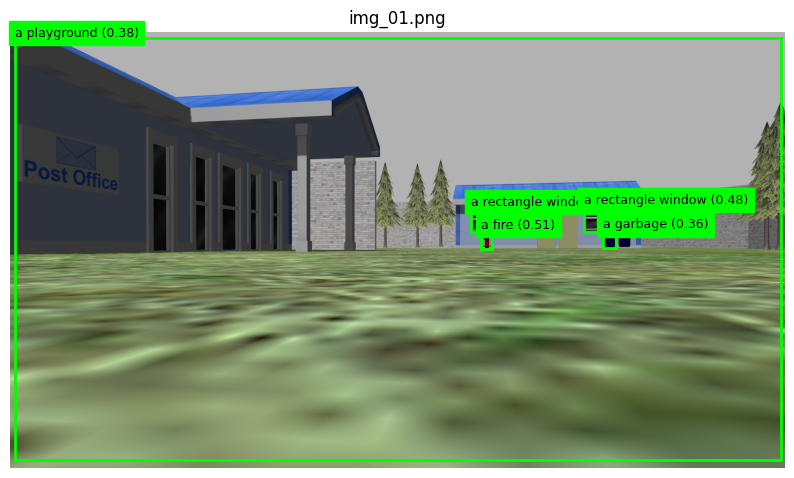

In [6]:
fname = image_files[0]
image = load_image(fname)

detect(image, OBJECT_PROMPTS)   # warm-up run (the first run is always slow)
dets, seconds = detect(image, OBJECT_PROMPTS)

print(f"{fname}: {len(dets)} detections in {seconds * 1000:.0f} ms")
for d in dets:
    print(d)
draw_detections(image, dets, fname)

## 7. Run on all images

Saves an annotated copy of every image and a CSV of all detections into `grounding_dino_results` inside your folder.

In [7]:
import pandas as pd

rows = []
for fname in image_files:
    image = load_image(fname)
    dets, seconds = detect(image, OBJECT_PROMPTS)

    if not dets:
        rows.append({"image": fname, "label": None, "score": None, "box": None,
                     "time_ms": round(seconds * 1000, 1)})
    for d in dets:
        rows.append({"image": fname, "label": d["label"], "score": d["score"],
                     "box": d["box"], "time_ms": round(seconds * 1000, 1)})

    draw_detections(image, dets, fname,
                    save_path=os.path.join(RESULTS_FOLDER, f"annotated_{os.path.splitext(fname)[0]}.png"),
                    display=False)

df = pd.DataFrame(rows)
df.to_csv(os.path.join(RESULTS_FOLDER, "detections_general_prompts.csv"), index=False)

print(f"Images processed: {len(image_files)}")
print(f"Total detections: {df['label'].notna().sum()}")
print(f"Average time per image: {df.groupby('image')['time_ms'].first().mean():.0f} ms")
df.head(20)

Images processed: 10
Total detections: 81
Average time per image: 490 ms


,image,label,score,box,time_ms
0,img_01.png,a rectangle window,0.495,"[1206, 433, 1244, 495]",572.3
1,img_01.png,a fire,0.511,"[1167, 491, 1194, 537]",572.3
2,img_01.png,a rectangle window,0.502,"[1141, 434, 1178, 495]",572.3
3,img_01.png,a rectangle window,0.476,"[1421, 430, 1461, 494]",572.3
4,img_01.png,a playground,0.378,"[11, 15, 1909, 1059]",572.3
5,img_01.png,a garbage,0.359,"[1468, 490, 1501, 535]",572.3
6,img_02.png,a fire,0.684,"[1688, 484, 1722, 544]",485.8
7,img_02.png,a rectangle window,0.425,"[1790, 422, 1816, 494]",485.8
8,img_02.png,a rectangle window,0.378,"[1677, 408, 1705, 485]",485.8
9,img_02.png,a office garage door,0.357,"[196, 149, 1872, 552]",485.8


## 8. Check against what's really in each image (optional, but most useful)

Fill in `EXPECTED` with the objects that are actually in each image (use the same wording as `OBJECT_PROMPTS`). You don't have to list every image; unlisted ones are skipped.

This answers two questions:
1. **Did it find the right objects?** (found / missed / extra)
2. **Are the confidence scores meaningful?** Correct detections should have clearly higher scores than wrong ones. Your clarifying-question idea depends on this.

In [8]:
EXPECTED = {
    "img_01.png": ["a garbage can", "a fire hydrant", "a post office", "a tree"],
    "img_02.png": ["a garbage can", "a fire hydrant", "a post office", "a tree"],
    "img_03.png": ["a stop sign", "a triffic drum", "a fountain", "a fire hydrant"],
    "img_04.png": ["a mailbox"],
    "img_05.png": ["a triffic drum", "a mailbox", "a fire hydrant"],
    "img_06.png": ["a tree", "a fountain", "a fire hydrant"],
    "img_07.png": ["a pickup truck", "a car"],
    "img_08.png": ["a stop sign", "a triffic drum", "a fountain", "a fire hydrant"],
    "img_09.png": ["a mailbox", "a fountain", "a garage door"],
    "img_10.png": ["a slide", "a playground", "a triffic drum", "a fountain", "a fire hydrant"],
}


def normalize(text):
    text = (text or "").lower().strip()
    for article in ("a ", "an ", "the "):
        if text.startswith(article):
            text = text[len(article):]
    return text


def is_match(detected, expected):
    d, e = normalize(detected), normalize(expected)
    return bool(d) and (d in e or e in d)


summary_rows = []
correct_scores, wrong_scores = [], []

for fname, expected_objects in EXPECTED.items():
    image_dets = df[(df["image"] == fname) & df["label"].notna()]
    found, missed = [], []
    for obj in expected_objects:
        (found if any(is_match(l, obj) for l in image_dets["label"]) else missed).append(obj)

    extra = []
    for _, row in image_dets.iterrows():
        if any(is_match(row["label"], obj) for obj in expected_objects):
            correct_scores.append(row["score"])
        else:
            wrong_scores.append(row["score"])
            extra.append(f'{row["label"]} ({row["score"]:.2f})')

    summary_rows.append({"image": fname, "found": found, "missed": missed, "extra": extra})

if summary_rows:
    summary = pd.DataFrame(summary_rows)
    summary.to_csv(os.path.join(RESULTS_FOLDER, "accuracy_check.csv"), index=False)

    total_expected = sum(len(v) for v in EXPECTED.values())
    total_found = sum(len(r["found"]) for r in summary_rows)
    print(f"Found {total_found} of {total_expected} expected objects "
          f"({100 * total_found / max(total_expected, 1):.0f}%)")
    print(f"Wrong (extra) detections: {len(wrong_scores)}")
    if correct_scores:
        print(f"Average score, correct detections: {sum(correct_scores) / len(correct_scores):.2f}")
    if wrong_scores:
        print(f"Average score, wrong detections:   {sum(wrong_scores) / len(wrong_scores):.2f}")
    display(summary)
else:
    print("Fill in EXPECTED above first.")

Found 16 of 33 expected objects (48%)
Wrong (extra) detections: 64
Average score, correct detections: 0.51
Average score, wrong detections:   0.44


,image,found,missed,extra
0,img_01.png,"[a garbage can, a fire hydrant]","[a post office, a tree]","[a rectangle window (0.49), a rectangle window..."
1,img_02.png,[a fire hydrant],"[a garbage can, a post office, a tree]","[a rectangle window (0.42), a rectangle window..."
2,img_03.png,"[a stop sign, a fountain, a fire hydrant]",[a triffic drum],"[a post office (0.36), a playground (0.37), a ..."
3,img_04.png,[],[a mailbox],"[garage door (0.55), a playground (0.40), a re..."
4,img_05.png,[a mailbox],"[a triffic drum, a fire hydrant]","[a firent (0.65), a garbage (0.69), a round wi..."
5,img_06.png,[a fountain],"[a tree, a fire hydrant]","[a firent (0.74), garage door (0.56), a rectan..."
6,img_07.png,[a pickup truck],[a car],"[a rectangle window window (0.41), a post offi..."
7,img_08.png,[a fire hydrant],"[a stop sign, a triffic drum, a fountain]","[a round window (0.63), a rectangle window (0...."
8,img_09.png,"[a mailbox, a fountain, a garage door]",[],"[a rectangle window (0.47), a rectangle window..."
9,img_10.png,"[a slide, a fountain, a fire hydrant]","[a playground, a triffic drum]","[garage door (0.53), a rectangle window (0.44)..."


## 9. Specific prompts (the kind your path-finding agent will send)

Asking for things like *"a blue mailbox next to a garage door"*, not just *"a mailbox"*. Test that here.

Include some **decoy** prompts too: objects that are *not* in the image. If the model returns high scores for things that aren't there, that's important to know before you trust its confidence.

/usr/local/lib/python3.13/dist-packages/transformers/models/grounding_dino/processing_grounding_dino.py:94: FutureWarning: The key `labels` is will return integer ids in `GroundingDinoProcessor.post_process_grounded_object_detection` output since v4.51.0. Use `text_labels` instead to retrieve string object names.
  warnings.warn(self.message, FutureWarning)


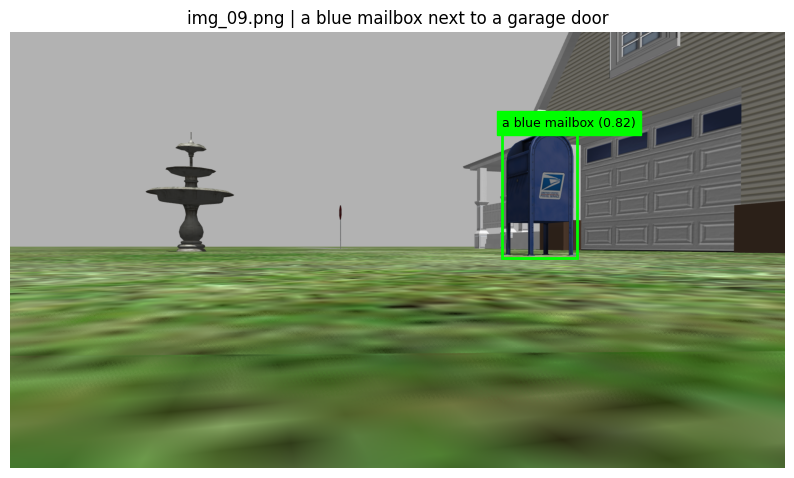

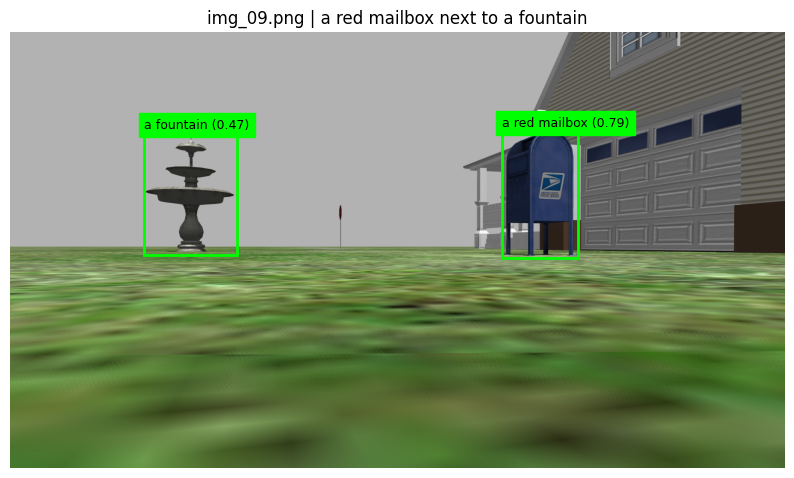

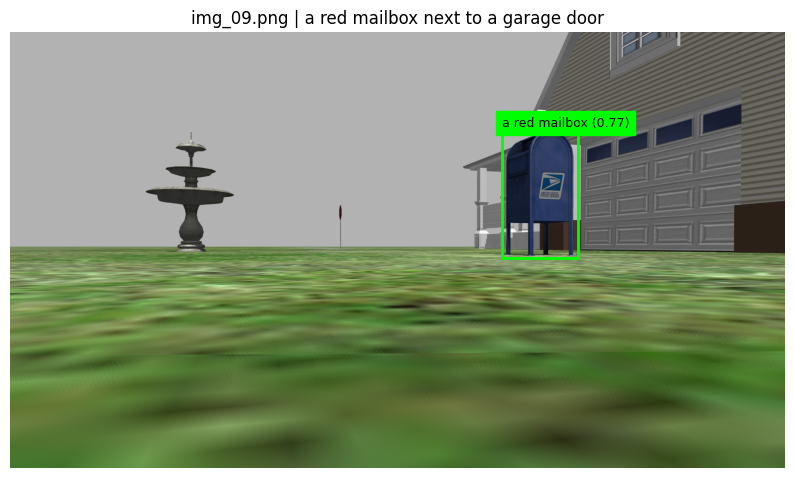

,image,prompt,really_there,detections,best_score
0,img_09.png,a blue mailbox next to a garage door,True,1,0.824
1,img_09.png,a red mailbox next to a fountain,False,2,0.789
2,img_09.png,a red mailbox next to a garage door,False,1,0.771


In [9]:
SPECIFIC_TESTS = [                              # <-- EDIT: (image file, prompt, is it really there?)
    ("img_09.png", "a blue mailbox next to a garage door", True),
    ("img_09.png", "a red mailbox next to a fountain", False),   # decoy
    ("img_09.png", "a red mailbox next to a garage door", False), # decoy
]

specific_rows = []
for fname, prompt, really_there in SPECIFIC_TESTS:
    image = load_image(fname)
    dets, _ = detect(image, [prompt])
    best = max((d["score"] for d in dets), default=0.0)
    specific_rows.append({"image": fname, "prompt": prompt, "really_there": really_there,
                          "detections": len(dets), "best_score": best})
    draw_detections(image, dets, f"{fname} | {prompt}")

if specific_rows:
    specific_df = pd.DataFrame(specific_rows)
    specific_df.to_csv(os.path.join(RESULTS_FOLDER, "specific_prompt_tests.csv"), index=False)
    display(specific_df)
else:
    print("Fill in SPECIFIC_TESTS above first.")

## 10. Save object crops for Step 3 (BLIP-2)

Saves each detected object as its own small image. In Step 3, BLIP-2 will describe these crops, which is exactly what the perception agent does.

In [10]:
CROPS_FOLDER = os.path.join(RESULTS_FOLDER, "crops")
os.makedirs(CROPS_FOLDER, exist_ok=True)

crop_count = 0
for fname in image_files:
    image = load_image(fname)
    image_dets = df[(df["image"] == fname) & df["label"].notna()]
    for i, (_, row) in enumerate(image_dets.iterrows()):
        x0, y0, x1, y1 = row["box"]
        crop = image.crop((x0, y0, x1, y1))
        label = normalize(row["label"]).replace(" ", "_") or "object"
        crop.save(os.path.join(CROPS_FOLDER,
                               f"{os.path.splitext(fname)[0]}_{i}_{label}_{row['score']:.2f}.png"))
        crop_count += 1

print(f"Saved {crop_count} crops to {CROPS_FOLDER}")

Saved 81 crops to /content/drive/MyDrive/gazebo_dataset_01172026/grounding_dino_dataset/grounding_dino_results/crops
